# 10 — Practical Case Study: A Designed Thermal Switch

By the end of this notebook you will be able to:

- Carry a single designed sequence through a full ViennaRNA workflow: MFE folding,
  suboptimal enumeration, ensemble/partition-function analysis, constrained folding,
  and a temperature sweep — using one sequence, one consistent set of questions.
- Translate base-pair probabilities into **two-state population fractions** via the
  Boltzmann relation, and use that to read a "switch temperature" off a plot.
- Use a hard constraint to model an external event (e.g., a binding partner) that
  overrides the sequence's own thermodynamic preference, and quantify its cost.
- Assemble the visualization techniques from notebook 09 into a final before/after
  comparison figure that tells the whole story in one image.

**Prerequisites**: this notebook draws on every previous notebook in the series —
[02](02_mfe_folding.ipynb) (MFE), [03](03_partition_probabilities.ipynb) (partition
function, bpp, entropy), [04](04_suboptimal_structures.ipynb) (`subopt`),
[05](05_constraints.ipynb) (hard constraints), [08](08_environment_effects.ipynb)
(temperature sweeps), and [09](09_visualization.ipynb) (custom and comparative
diagrams). None of those notebooks are required reading to follow this one, but each
section here reuses a technique introduced there, with a pointer back.


## 1. Introduction and motivation

Real analyses rarely stop at "fold this sequence and look at the structure". A typical
workflow looks more like: *fold it, check whether the answer is robust, see whether
the ensemble agrees with the single best structure, ask how an external event (a
ligand, a binding partner, a temperature change) would change the answer, and finally
make a figure that communicates all of that at once.*

This notebook runs exactly that workflow on one designed sequence,

```
switch_seq = "CCCCAAAAGGGGAAAACCCCAAAAGGGG"
```

which notebooks 03, 05, and 09 have already shown has **two competing folds** roughly
0.2 kcal/mol apart: a "two separate hairpins" structure and a "one nested helix"
structure. Here we go one step further and show that this sequence is, in effect, a
**designed thermal switch** — which of the two folds dominates depends on
temperature, and an external constraint can override that preference entirely.

**Roadmap**:

- **Section 3** sets up the sequence and reviews its two competing structures (MFE +
  `subopt`, from notebooks 02 and 04).
- **Section 4** quantifies the ensemble's preference between the two structures using
  base-pair probabilities and the two-state Boltzmann relation (from notebook 03).
- **Section 5** sweeps temperature and finds the **switch temperature** where the
  preference flips (from notebook 08).
- **Section 6** uses a hard constraint to *force* the low-temperature structure even
  at a temperature where it is no longer preferred — modeling how a binding event
  might lock in a conformation (from notebook 05).
- **Section 7** assembles a final before/after dashboard (from notebook 09).


## 2. Theoretical background: from energies to populations to a switch

### 2.1 Two-state populations from free energies

If a sequence's ensemble is dominated by two structures $A$ and $B$ with free
energies $\Delta G_A$ and $\Delta G_B$, the **Boltzmann distribution** gives their
relative populations directly:

$$
\frac{p_B}{p_A} = \exp\!\left(-\frac{\Delta G_B - \Delta G_A}{RT}\right),
\qquad
p_A + p_B \approx 1,
$$

where $R = 0.0019872\ \text{kcal}\,\text{mol}^{-1}\text{K}^{-1}$ and $T$ is the
absolute temperature in Kelvin. A $\Delta G_B - \Delta G_A$ of $+0.2$ kcal/mol at
$37^\circ\text{C}$ ($T \approx 310.15\,\text{K}$, so $RT \approx 0.616$ kcal/mol) gives
$p_B/p_A = e^{-0.2/0.616} \approx 0.72$ — close to a 50/50 split, consistent with two
structures that are "near-degenerate".

### 2.2 Reading populations directly from `bpp()`

The two-state formula above is an *approximation* — the true ensemble contains many
more structures. Notebook 03 introduced something more direct: `fc.bpp()` gives the
**marginal probability** $p_{ij}$ that positions $i$ and $j$ pair, summed over the
*entire* ensemble, no two-state assumption required. If structures $A$ and $B$ each
contain a pair that the other does not — a **signature pair** — then $p_{ij}$ for that
signature pair *is* (to good approximation) the population of the structure that
contains it. Section 4 finds such a pair for `switch_seq` and tracks it directly.

### 2.3 Temperature changes the energy gap

Both $\Delta G_A$ and $\Delta G_B$ depend on temperature (notebook 08), but not by the
same amount — different structures have different enthalpy/entropy balances. If the
*sign* of $\Delta G_B - \Delta G_A$ changes somewhere in the temperature range, the
MFE structure itself will flip at that temperature: a **switch temperature**
$T_{\text{switch}}$. Section 5 finds $T_{\text{switch}}$ for `switch_seq` by repeating
notebook 08's temperature sweep and tracking the signature-pair probabilities from
Section 4.

### 2.4 Theory-to-API map for this notebook

| Concept | API | Section |
| :--- | :--- | :--- |
| MFE structure and energy | `fc.mfe()` | 3 |
| Alternative low-energy structures | `fc.subopt(delta)` | 3 |
| Marginal pairing probabilities $p_{ij}$ | `fc.pf()`, `fc.bpp()` | 4 |
| Positional entropy | `fc.positional_entropy()` | 4 |
| Temperature-dependent model | `RNA.md()`, `.temperature`, `fc.exp_params_rescale()` | 5 |
| Forcing a structure via constraint | `fc.hc_add_bp(i, j, ...)` | 6 |
| Custom/comparative structure diagrams | `RNA.get_xy_coordinates`, comparative arcs | 7 |


## 3. Setup and Step 1 — baseline characterization

This cell sets up the consistent theme and the helper functions carried over from
notebook 09 (`get_coordinates`, `plot_custom_structure`, `plot_comparative_arcs`,
`plot_arc_diagram`, `plot_mountain`, `plot_dot_plot`, `plot_forgi_structure`,
`dotbracket_to_pairs`). It then folds `switch_seq` at $37^\circ\text{C}$ and runs
`fc.subopt(...)` to confirm it has exactly two structures within 0.3 kcal/mol of each
other — the two-state landscape this whole notebook is about.


In [1]:
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

R_GAS = 0.0019872  # kcal / (mol K)


def dotbracket_to_pairs(structure):
    '''Return 1-indexed base-pair tuples (i, j), i < j.'''
    stack, pairs = [], []
    for pos, ch in enumerate(structure, start=1):
        if ch == "(":
            stack.append(pos)
        elif ch == ")":
            pairs.append((stack.pop(), pos))
    return pairs


def get_coordinates(structure):
    '''Return an (n, 2) array of ViennaRNA layout coordinates (see notebook 09).'''
    xy = RNA.get_xy_coordinates(structure)
    n = len(structure)
    return np.array([[xy.get(i).X, xy.get(i).Y] for i in range(n)])


def plot_custom_structure(sequence, structure, ax, values=None, cmap="rocket_r",
                           vmin=0.0, vmax=1.0, title=None, fig=None, colorbar_label=None):
    '''Structure diagram from raw layout coordinates, optionally colored by `values`.'''
    coords = get_coordinates(structure)
    pairs = dotbracket_to_pairs(structure)

    ax.plot(coords[:, 0], coords[:, 1], "-", color="#CBD5E1", lw=1.6, zorder=1)
    for i, j in pairs:
        ax.plot([coords[i - 1, 0], coords[j - 1, 0]], [coords[i - 1, 1], coords[j - 1, 1]],
                "-", color="#94A3B8", lw=1.6, zorder=1)

    if values is None:
        sc = ax.scatter(coords[:, 0], coords[:, 1], color=PALETTE[0], s=240,
                         zorder=2, edgecolors="white", linewidths=0.8)
    else:
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=values, cmap=cmap, vmin=vmin, vmax=vmax,
                         s=240, zorder=2, edgecolors="white", linewidths=0.8)
        if fig is not None:
            fig.colorbar(sc, ax=ax, shrink=0.7, label=colorbar_label or "value")

    for i, base in enumerate(sequence):
        ax.text(coords[i, 0], coords[i, 1], base, ha="center", va="center", fontsize=8, zorder=3)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title or "Custom structure diagram")
    return sc


def plot_forgi_structure(sequence, structure, ax, title=None, lighten=0.25):
    '''Structure diagram colored by element type, via forgi (see notebook 01/09).'''
    bg = fgb.BulgeGraph.from_dotbracket(structure, sequence)
    fvm.plot_rna(bg, ax=ax, lighten=lighten, text_kwargs={"fontsize": 8})
    ax.set_aspect("equal")
    ax.set_title(title or "forgi structure diagram")


def plot_arc_diagram(sequence, structure, ax, title=None):
    '''Base pairs as arcs above the sequence (see notebook 01).'''
    n = len(sequence)
    positions = np.arange(1, n + 1)
    ax.plot(positions, np.zeros(n), color="#CBD5E1", linewidth=2, zorder=1)
    for position, base in zip(positions, sequence):
        ax.text(position, -0.16, base, ha="center", va="center", fontsize=9)

    for left, right in dotbracket_to_pairs(structure):
        center = (left + right) / 2
        radius = (right - left) / 2
        xs = np.linspace(left, right, 120)
        ys = np.sqrt(np.maximum(radius**2 - (xs - center)**2, 0))
        ax.plot(xs, ys, color=PALETTE[0], linewidth=2.4, zorder=2)

    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(-0.4, max(1.0, n / 2 + 0.4))
    ax.axis("off")
    ax.set_title(title or "Arc diagram")


def plot_comparative_arcs(sequence, structure_a, structure_b, ax,
                           label_a="A", label_b="B", title=None):
    '''Mirrored arc diagram comparing two structures (see notebook 09).'''
    n = len(sequence)
    positions = np.arange(1, n + 1)
    pairs_a = set(dotbracket_to_pairs(structure_a))
    pairs_b = set(dotbracket_to_pairs(structure_b))
    shared = pairs_a & pairs_b
    only_a = pairs_a - shared
    only_b = pairs_b - shared

    ax.plot(positions, np.zeros(n), color="#CBD5E1", linewidth=2, zorder=1)
    for position, base in zip(positions, sequence):
        ax.text(position, 0, base, ha="center", va="center", fontsize=8, zorder=3,
                bbox=dict(boxstyle="circle,pad=0.18", facecolor="white", edgecolor="none"))

    def draw_arcs(pairs, sign, color):
        for left, right in pairs:
            center = (left + right) / 2
            radius = (right - left) / 2
            xs = np.linspace(left, right, 120)
            ys = sign * np.sqrt(np.maximum(radius**2 - (xs - center)**2, 0))
            ax.plot(xs, ys, color=color, linewidth=2.6, zorder=2)

    draw_arcs(only_a, 1, PALETTE[0])
    draw_arcs(only_b, -1, PALETTE[1])
    draw_arcs(shared, 1, PALETTE[2])
    draw_arcs(shared, -1, PALETTE[2])

    half = n / 2 + 0.6
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(-half, half)
    ax.axis("off")
    ax.set_title(title or f"{label_a} (above) vs. {label_b} (below)")


def loop_depth_profile(structure):
    '''Per-position pairing depth (see notebook 01).'''
    depth, profile = 0, []
    for symbol in structure:
        if symbol == "(":
            depth += 1
            profile.append(depth)
        elif symbol == ")":
            profile.append(depth)
            depth -= 1
        else:
            profile.append(depth)
    return profile


def plot_mountain(sequence, structure, ax, title=None, color=None):
    '''Mountain plot: pairing depth vs. sequence position (see notebook 01).'''
    color = color or PALETTE[4]
    positions = np.arange(1, len(sequence) + 1)
    depths = loop_depth_profile(structure)
    ax.step(positions, depths, where="mid", color=color, linewidth=2.4)
    ax.fill_between(positions, depths, step="mid", color=color, alpha=0.25)
    ax.set_xlim(0.5, len(sequence) + 0.5)
    ax.set_ylim(0, max(depths) + 1)
    ax.set_xlabel("Sequence position")
    ax.set_ylabel("Pairing depth")
    ax.set_title(title or "Mountain plot")
    sns.despine(ax=ax)


def plot_dot_plot(sequence, fc, mfe_structure, ax, title=None, tick_step=1):
    '''Dot plot: upper triangle = bpp, lower triangle = MFE pairs (see notebook 03/09).'''
    n = len(sequence)
    bpp = np.array(fc.bpp())[1:, 1:]
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            matrix[i, j] = bpp[i, j]
    for left, right in dotbracket_to_pairs(mfe_structure):
        matrix[right - 1, left - 1] = 1.0

    sns.heatmap(matrix, ax=ax, cmap="rocket_r", vmin=0, vmax=1,
                 cbar_kws={"label": "probability / MFE pair"}, square=True)
    ax.set_xlabel("Position $j$")
    ax.set_ylabel("Position $i$")
    ax.set_title(title or "Dot plot")
    tick_positions = np.arange(0, n, tick_step) + 0.5
    tick_labels = np.arange(1, n + 1, tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, rotation=0)


print(f"ViennaRNA Python module version: {getattr(RNA, '__version__', 'unknown')}")


ViennaRNA Python module version: 2.7.2


In [2]:
switch_seq = "CCCCAAAAGGGGAAAACCCCAAAAGGGG"
fc_37 = RNA.fold_compound(switch_seq)
structure_mfe, mfe_37 = fc_37.mfe()

subopt_structures = []
seen = set()
for s in fc_37.subopt(50):
    if s.structure not in seen:
        seen.add(s.structure)
        subopt_structures.append((s.structure, s.energy))

print(f"{switch_seq}  (n = {len(switch_seq)})\n")
for structure, energy in subopt_structures:
    tag = "  <- MFE" if structure == structure_mfe else ""
    print(f"{structure}  ({energy:5.2f} kcal/mol){tag}")

structure_A, energy_A = subopt_structures[0]
structure_B, energy_B = subopt_structures[1]
delta_G = energy_B - energy_A
print(f"\nDelta G (B - A) = {delta_G:.2f} kcal/mol")


CCCCAAAAGGGGAAAACCCCAAAAGGGG  (n = 28)

((((....))))....((((....))))  (-13.20 kcal/mol)  <- MFE
((((....((((....))))....))))  (-13.00 kcal/mol)

Delta G (B - A) = 0.20 kcal/mol


**Reading the output**: within 0.5 kcal/mol of the MFE, `subopt` finds exactly two
structures. We call the lower-energy one **state A** — two separate 4-bp hairpins —
and the other **state B** — one outer helix nested around one inner hairpin (the same
pair notebook 09 examined with a comparative arc diagram, where *every* base pair
changes partner between the two states). At $37^\circ\text{C}$ they are separated by
only $\Delta G = E_B - E_A \approx 0.2$ kcal/mol.


## 4. Step 2 — how much does the ensemble prefer state A?

The two-state formula from Section 2.1 predicts $p_B/p_A = e^{-\Delta G / RT}$. Before
trusting that approximation, Section 2.2 suggested checking it against a **signature
pair** read directly from `fc.bpp()`. Scanning the base-pair probability matrix for
`switch_seq`, the pair $(1,12)$ belongs only to state A and the pair $(1,28)$ belongs
only to state B — so $p_{1,12}$ and $p_{1,28}$ are direct ensemble estimates of
$p_A$ and $p_B$.


In [3]:
fc_37.pf()
bpp_37 = np.array(fc_37.bpp())
entropy_37 = np.array(fc_37.positional_entropy())[1:]

p_A_signature = bpp_37[1, 12]
p_B_signature = bpp_37[1, 28]

# Two-state prediction from Section 2.1, for comparison
T_kelvin = 37.0 + 273.15
ratio_predicted = np.exp(-delta_G / (R_GAS * T_kelvin))
p_A_predicted = 1.0 / (1.0 + ratio_predicted)
p_B_predicted = 1.0 - p_A_predicted

summary_37 = pd.DataFrame({
    "quantity": ["p(1,12)  [state A signature]", "p(1,28)  [state B signature]"],
    "from bpp()": [p_A_signature, p_B_signature],
    "two-state prediction": [p_A_predicted, p_B_predicted],
})
summary_37


,quantity,from bpp(),two-state prediction
0,"p(1,12) [state A signature]",0.556851,0.580421
1,"p(1,28) [state B signature]",0.401722,0.419579


**Reading the table**: the direct `bpp()` read-out and the two-state Boltzmann
prediction agree to within a couple of percent — at $37^\circ\text{C}$, `switch_seq`
spends roughly 56% of the ensemble in state A and 40% in state B (the remaining ~4%
in other minor structures). This is a genuinely "almost coin-flip" sequence: a small
perturbation — a mutation, a binding partner, or a temperature change — could easily
tip the balance. Section 5 shows that temperature alone is enough.


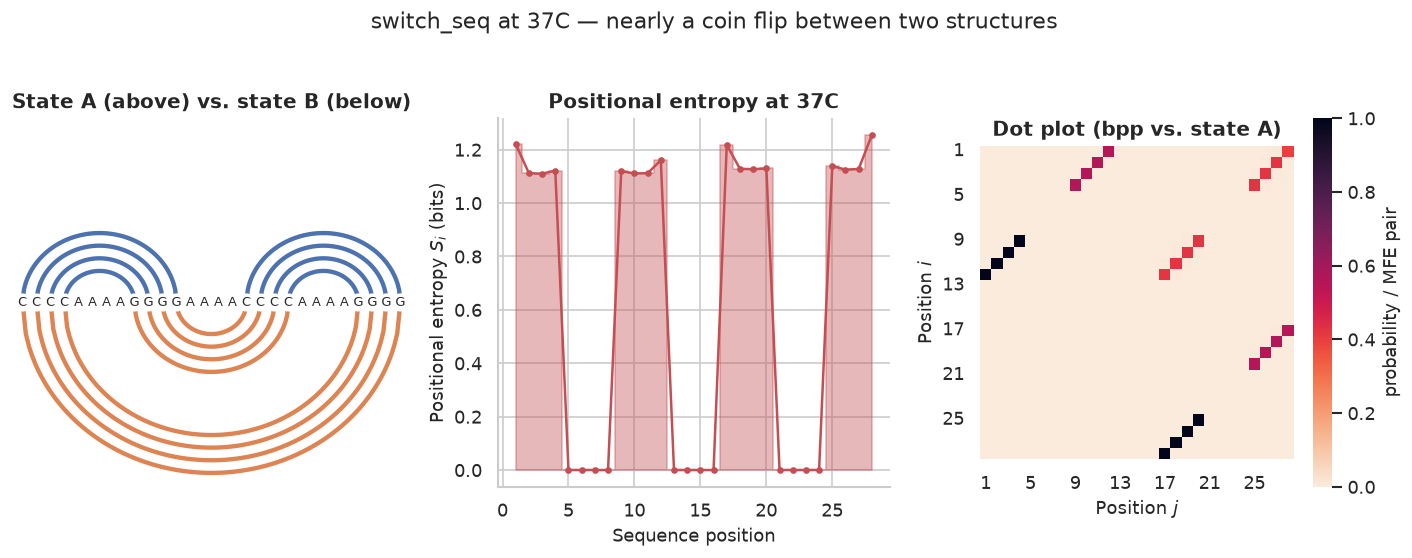

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
plot_comparative_arcs(switch_seq, structure_A, structure_B, ax=axes[0],
                       label_a=f"A ({energy_A:.2f})", label_b=f"B ({energy_B:.2f})",
                       title="State A (above) vs. state B (below)")

positions = np.arange(1, len(switch_seq) + 1)
axes[1].fill_between(positions, entropy_37, color=PALETTE[3], alpha=0.4, step="mid")
axes[1].plot(positions, entropy_37, color=PALETTE[3], marker="o", ms=3, lw=1.5)
axes[1].set_xlabel("Sequence position")
axes[1].set_ylabel(r"Positional entropy $S_i$ (bits)")
axes[1].set_title("Positional entropy at 37C")
sns.despine(ax=axes[1])

plot_dot_plot(switch_seq, fc_37, structure_A, ax=axes[2], title="Dot plot (bpp vs. state A)", tick_step=4)

fig.suptitle(f"switch_seq at 37C — nearly a coin flip between two structures", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: the comparative arc diagram (left) shows the two states share
no base pairs at all (no green arcs) — every position's partner changes between A and
B. The entropy profile (middle) is elevated (1–2 bits) across almost every paired
position, reflecting exactly this ambiguity — high uncertainty about *which* partner,
even where the probability of being paired with *something* is high. The dot plot
(right) makes this concrete: alongside the lower-triangle state-A pairs, the upper
triangle shows substantial off-diagonal probability mass at the state-B pairs (e.g.,
near position 28) — visible as a secondary diagonal streak.


## 5. Step 3 — finding the switch temperature

Following notebook 08's pattern, we recompute `bpp()` at a series of temperatures,
each time constructing a fresh `RNA.md()` with `.temperature` set and calling
`fc.exp_params_rescale(mfe)` before `fc.pf()`. At each temperature we record the
state-A and state-B signature-pair probabilities *and* the MFE structure itself.


In [5]:
temperatures = np.arange(10, 91, 2)
sweep_rows = []
for T in temperatures:
    md_t = RNA.md()
    md_t.temperature = float(T)
    fc_t = RNA.fold_compound(switch_seq, md_t)
    structure_t, mfe_t = fc_t.mfe()
    fc_t.exp_params_rescale(mfe_t)
    fc_t.pf()
    bpp_t = np.array(fc_t.bpp())
    sweep_rows.append({
        "temperature": T,
        "p_A": bpp_t[1, 12],
        "p_B": bpp_t[1, 28],
        "mfe_structure": structure_t,
        "mfe_is_A": structure_t == structure_A,
    })

sweep = pd.DataFrame(sweep_rows)
switch_index = (sweep["mfe_is_A"] != sweep["mfe_is_A"].shift()) & sweep["mfe_is_A"].shift().notna()
switch_temperatures = sweep.loc[switch_index, "temperature"].tolist()
print("MFE switches structure near T =", switch_temperatures, "C")
sweep.iloc[::5]


MFE switches structure near T = [42] C


,temperature,p_A,p_B,mfe_structure,mfe_is_A
0,10,0.946245,0.051779,((((....))))....((((....)))),True
5,20,0.863183,0.129982,((((....))))....((((....)))),True
10,30,0.705823,0.273175,((((....))))....((((....)))),True
15,40,0.489436,0.456827,((((....))))....((((....)))),True
20,50,0.284899,0.602813,((((....((((....))))....)))),False
25,60,0.146052,0.655050,((((....((((....))))....)))),False
30,70,0.071332,0.614626,((((....((((....))))....)))),False
35,80,0.037944,0.505067,((((....((((....))))....)))),False
40,90,0.026350,0.344891,((((....((((....))))....)))),False


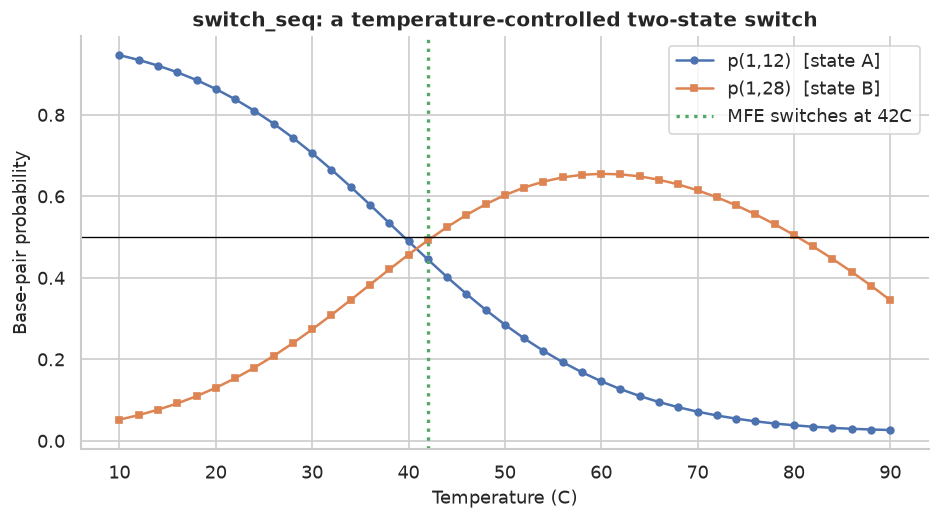

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep["temperature"], sweep["p_A"], marker="o", ms=4, label="p(1,12)  [state A]", color=PALETTE[0])
ax.plot(sweep["temperature"], sweep["p_B"], marker="s", ms=4, label="p(1,28)  [state B]", color=PALETTE[1])
for T_switch in switch_temperatures:
    ax.axvline(T_switch, color=PALETTE[2], linestyle=":", linewidth=2,
               label=f"MFE switches at {T_switch}C")
ax.axhline(0.5, color="black", linewidth=0.8)
ax.set_xlabel("Temperature (C)")
ax.set_ylabel("Base-pair probability")
ax.set_title("switch_seq: a temperature-controlled two-state switch")
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: at low temperature, state A dominates ($p_{1,12} \to 1$); as
temperature rises, the two curves cross, and above the switch temperature state B
dominates. The crossing point of the two probability curves coincides with the
temperature at which the *MFE structure itself* flips from A to B — temperature alone
converts `switch_seq` from "two separate hairpins" into "one nested helix". This is
the same phenomenon as notebook 08's melting curve, but here it is a switch *between
two folded structures*, not a transition from folded to unfolded.


## 6. Step 4 — overriding the switch with a constraint

Suppose a binding partner (a protein, a complementary oligo, a metabolite contacting
the backbone) makes pair $(1,12)$ — the state-A signature pair — energetically
favorable no matter what, by physically holding those two positions together. We can
model the *limiting case* of such an interaction with a **hard constraint**
(notebook 05): `fc.hc_add_bp(1, 12, RNA.CONSTRAINT_CONTEXT_ALL_LOOPS)` forces that pair
to form in the MFE structure.

We apply this constraint at $70^\circ\text{C}$ — comfortably above the switch
temperature found in Section 5, where state B is the unconstrained MFE — and ask two
questions: (1) does the constraint successfully recover state A, and (2) what does
that cost in free energy?


In [7]:
T_high = 70.0
md_high = RNA.md()
md_high.temperature = T_high

fc_unconstrained = RNA.fold_compound(switch_seq, md_high)
structure_unconstrained, mfe_unconstrained = fc_unconstrained.mfe()

fc_constrained = RNA.fold_compound(switch_seq, md_high)
fc_constrained.hc_add_bp(1, 12, RNA.CONSTRAINT_CONTEXT_ALL_LOOPS)
structure_constrained, mfe_constrained = fc_constrained.mfe()

print(f"At {T_high:.0f}C:")
print(f"  unconstrained MFE: {structure_unconstrained}  ({mfe_unconstrained:.2f} kcal/mol)"
      f"  [{'state A' if structure_unconstrained == structure_A else 'state B'}]")
print(f"  constrained MFE:   {structure_constrained}  ({mfe_constrained:.2f} kcal/mol)"
      f"  [{'state A' if structure_constrained == structure_A else 'state B'}]")
print(f"\n  cost of forcing state A at {T_high:.0f}C: "
      f"{mfe_constrained - mfe_unconstrained:.2f} kcal/mol")


At 70C:
  unconstrained MFE: ((((....((((....))))....))))  (-5.62 kcal/mol)  [state B]
  constrained MFE:   ((((....))))....((((....))))  (-4.05 kcal/mol)  [state A]

  cost of forcing state A at 70C: 1.57 kcal/mol


In [8]:
fc_constrained.exp_params_rescale(mfe_constrained)
fc_constrained.pf()
bpp_constrained = np.array(fc_constrained.bpp())

fc_unconstrained.exp_params_rescale(mfe_unconstrained)
fc_unconstrained.pf()
bpp_unconstrained = np.array(fc_unconstrained.bpp())

override_summary = pd.DataFrame({
    "quantity": ["p(1,12)  [state A]", "p(1,28)  [state B]"],
    f"unconstrained @ {T_high:.0f}C": [bpp_unconstrained[1, 12], bpp_unconstrained[1, 28]],
    f"constrained @ {T_high:.0f}C": [bpp_constrained[1, 12], bpp_constrained[1, 28]],
})
override_summary


,quantity,unconstrained @ 70C,constrained @ 70C
0,"p(1,12) [state A]",0.071332,0.846161
1,"p(1,28) [state B]",0.614626,0.000000


**Reading the output**: at $70^\circ\text{C}$, the unconstrained ensemble strongly
favors state B ($p_{1,28} \approx 0.6$, $p_{1,12} \approx 0.07$, consistent with
Section 5's sweep). Forcing pair $(1,12)$ flips the *entire* ensemble back to state A
($p_{1,12} \to 0.85$) at a cost of only about 1.6 kcal/mol — a single favorable
tertiary contact is easily within the range of a real binding interaction. This is the
same "hard constraint" mechanism from notebook 05, now used for a purpose notebook 05
didn't have: showing that an external interaction can **override a temperature-driven
preference**, not just resolve an ambiguity at a single fixed temperature.


## 7. Step 5 — the whole story in one figure

The final figure combines every technique used above into one before/after comparison
at $70^\circ\text{C}$: the unconstrained ensemble (favoring state B) on the left, and
the constrained ensemble (forced back into state A) on the right, each shown as a
probability-colored structure diagram (notebook 09) plus its dot plot (notebook 03).
A shared comparative arc diagram across the bottom shows the two MFE structures being
compared.


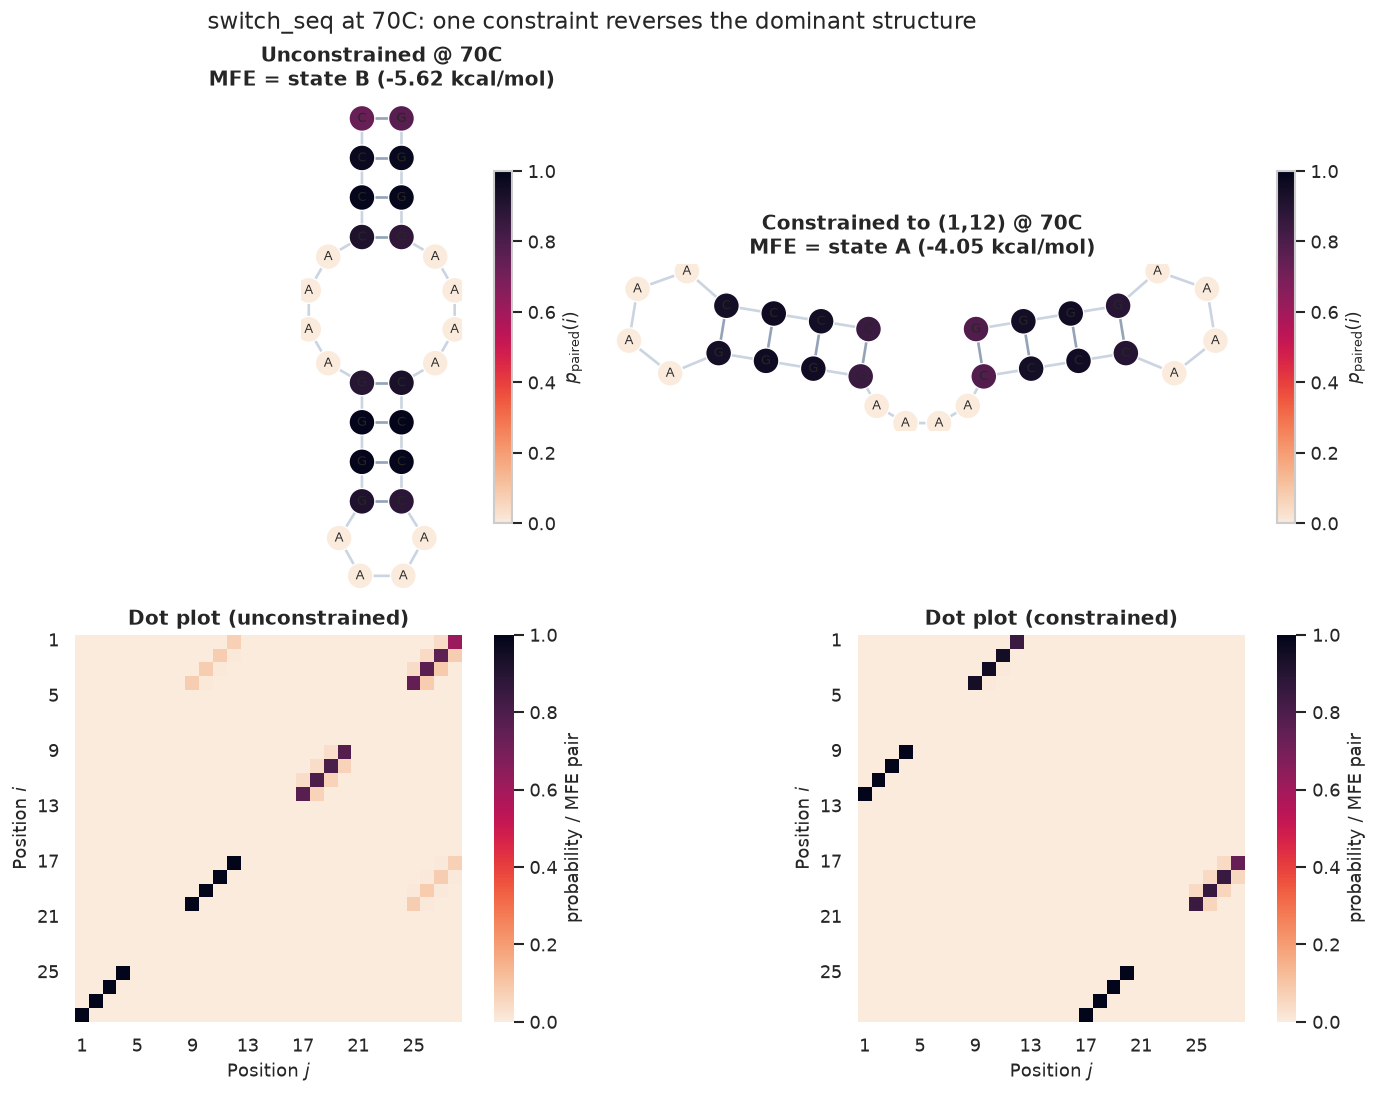

In [9]:
n = len(switch_seq)
p_paired_unconstrained = np.array([bpp_unconstrained[i, :].sum() + bpp_unconstrained[:, i].sum()
                                    for i in range(1, n + 1)])
p_paired_constrained = np.array([bpp_constrained[i, :].sum() + bpp_constrained[:, i].sum()
                                  for i in range(1, n + 1)])

fig = plt.figure(figsize=(13, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.3, 1])

ax_unc = fig.add_subplot(gs[0, 0])
ax_con = fig.add_subplot(gs[0, 1])
ax_dot_unc = fig.add_subplot(gs[1, 0])
ax_dot_con = fig.add_subplot(gs[1, 1])

plot_custom_structure(switch_seq, structure_unconstrained, ax=ax_unc,
                       values=p_paired_unconstrained, vmin=0, vmax=1, fig=fig,
                       colorbar_label=r"$p_{\mathrm{paired}}(i)$",
                       title=f"Unconstrained @ {T_high:.0f}C\n"
                             f"MFE = state B ({mfe_unconstrained:.2f} kcal/mol)")
plot_custom_structure(switch_seq, structure_constrained, ax=ax_con,
                       values=p_paired_constrained, vmin=0, vmax=1, fig=fig,
                       colorbar_label=r"$p_{\mathrm{paired}}(i)$",
                       title=f"Constrained to (1,12) @ {T_high:.0f}C\n"
                             f"MFE = state A ({mfe_constrained:.2f} kcal/mol)")
plot_dot_plot(switch_seq, fc_unconstrained, structure_unconstrained, ax=ax_dot_unc,
              title="Dot plot (unconstrained)", tick_step=4)
plot_dot_plot(switch_seq, fc_constrained, structure_constrained, ax=ax_dot_con,
              title="Dot plot (constrained)", tick_step=4)

fig.suptitle("switch_seq at 70C: one constraint reverses the dominant structure", fontsize=14)
plt.show()


**Reading the dashboard**: the left column shows the unconstrained system at
$70^\circ\text{C}$ — its structure diagram is colored almost uniformly dark (high
$p_{\text{paired}}$), and its dot plot's upper triangle has visible mass away from the
lower-triangle MFE pairs (state A pairs competing with the state-B MFE). The right
column shows the same sequence and temperature, but with pair $(1,12)$ forced: the
structure diagram now traces state A's topology, and the dot plot's upper and lower
triangles agree almost perfectly — the constraint has not just changed the MFE, it has
made the *entire ensemble* confident in a single structure. One sequence, one
temperature, two very different pictures — separated by a single base pair held in
place.


## 8. Best practices: a checklist for analyzing a new sequence

This case study followed a sequence of questions that generalizes beyond
`switch_seq`. When characterizing any new sequence, consider working through:

1. **MFE first** (`fc.mfe()`, notebook 02) — what is *the* answer, and what is its
   energy? Always report the energy alongside the structure; a structure without its
   energy can't be compared to anything.
2. **Suboptimals next** (`fc.subopt(delta)`, notebook 04) — is the MFE alone, or are
   there competitors within a few tenths of a kcal/mol? A lone MFE more than ~1
   kcal/mol below its nearest competitor is a much stronger claim than one with
   several near-degenerate alternatives.
3. **Ensemble view** (`fc.pf()`, `fc.bpp()`, `fc.positional_entropy()`, notebook 03) —
   does the ensemble agree with the MFE? Look for **signature pairs** that distinguish
   competing structures, and read their probabilities directly rather than relying
   only on the two-state approximation.
4. **Environment sensitivity** (`RNA.md()`, temperature/salt sweeps, notebook 08) — is
   the answer from steps 1–3 stable across the conditions your sequence will actually
   experience? A near-degenerate pair of structures (step 2) is exactly when this
   matters most, as Section 5 showed.
5. **Constraints for "what if"** (`fc.hc_add_bp`, `fc.sc_add_bp`, notebook 05) — can an
   external interaction (binding, modification, mutation) plausibly shift the balance
   found in steps 3–4? Hard constraints give you the *limiting case* cheaply, before
   reaching for a full mutation scan.
6. **One final figure** (notebook 09) — once you understand the system, build a single
   figure that would let someone else reach the same conclusions without rerunning
   your analysis. Comparative diagrams (arcs, dot plots, probability-colored
   structures) communicate *relationships between* structures, which is usually the
   actual finding — not just what any one structure looks like.

**Pitfall to avoid**: steps 1–3 are about the sequence *itself*; steps 4–5 are about
how it *responds to its environment*. It's tempting to stop at step 1 — but for a
sequence like `switch_seq`, the MFE alone (state A or state B, depending on which
temperature you happened to pick) tells you almost nothing about the more interesting
fact: that this sequence's fold is contingent on conditions at all.


## 9. Summary

- `switch_seq = "CCCCAAAAGGGGAAAACCCCAAAAGGGG"` has two structures within 0.2 kcal/mol
  of each other at $37^\circ\text{C}$ — a near-degenerate pair with **no shared base
  pairs**, found via `fc.mfe()` and `fc.subopt()` (Section 3).
- Base-pair probabilities for **signature pairs** read directly off `fc.bpp()` agree
  with the two-state Boltzmann prediction from their energy gap, giving population
  fractions of roughly 56%/40% at $37^\circ\text{C}$ (Section 4).
- A temperature sweep (Section 5) shows these populations — and even the MFE
  structure itself — cross over near a **switch temperature**, making `switch_seq` a
  designed two-state thermal switch.
- A hard constraint (Section 6) models an external interaction strong enough to
  **override** the temperature-driven preference at a cost of about 1.6 kcal/mol,
  and Section 7's dashboard shows the resulting before/after change across the whole
  ensemble, not just the MFE.

This is the last notebook in the ViennaRNA tutorial track. Together with the
[NUPACK notebooks](../) in this repository, you now have two complementary toolkits
for RNA secondary-structure analysis — ViennaRNA for single-sequence and comparative
folding with fine control over constraints and model parameters, and NUPACK for
multi-strand tube analysis and sequence design.


## 10. Exercises

1. **A finer switch temperature.** Section 5 swept temperature in steps of
   2$^\circ$C. Narrow the sweep to a 5$^\circ$C window around the switch temperature
   found there, using a step of 0.2$^\circ$C, and report $T_{\text{switch}}$ to one
   decimal place. Does the MFE-based switch temperature exactly match the
   probability-crossing temperature, or can they differ slightly?

2. **The other override.** Section 6 used a hard constraint on pair $(1,12)$ to force
   state A at $70^\circ\text{C}$. Design the opposite experiment: at a low temperature
   where state A is the unconstrained MFE (Section 5), find a hard constraint that
   forces state B, and compare its energetic cost to the 1.6 kcal/mol found in
   Section 6. Is overriding "in the direction temperature already favors at the
   *other* end of the range" cheaper or more expensive?

3. **A three-state sequence.** Every sequence in this notebook (and most of the
   series) has had at most two competing low-energy structures. Search for a short
   sequence (20-30 nt) with **three** structures within 1 kcal/mol of the MFE via
   `fc.subopt()`. Do signature pairs still work for distinguishing three states, or
   does the two-state formula from Section 2.1 need to be extended?
